Logistic Regression and Feature Importance after TT

In [ ]:
from pathlib import Path
import os
import sys

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "src" / "utils.py").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.utils import load_csv, data_path

# Real models using TT scores
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the data just a smidge
df_tt = load_csv('data/supervised_split.csv')

df_tt = df_tt.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

# Set up X and y values
y_tt = df_tt['rating'] >= df_tt['rating'].mean()

X_tt = df_tt.drop(columns=['rating', 'title', 'tag', 'rating_timestamp', 'tag_timestamp', 'userId', 'movieId', '(no genres listed)'])

# Train test split on the model and scale it
X_train, X_test, y_train, y_test = train_test_split(X_tt, y_tt, test_size=0.2, random_state=42)

scaler_tt = StandardScaler()

X_tt_train_scaled = scaler_tt.fit_transform(X_train)
X_tt_test_scaled = scaler_tt.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
#Logistic Regression and Feature Importance

#Run the Model and check accuracy 
log_model_tt = LogisticRegression(max_iter=1000)
log_model_tt.fit(X_tt_train_scaled, y_train)

print("Logistic Regression with TT Scores:")
print("Train Accuracy:", log_model_tt.score(X_tt_train_scaled, y_train))
print("Test Accuracy:", log_model_tt.score(X_tt_test_scaled, y_test))

print(f1_score(y_test, log_model_tt.predict(X_tt_test_scaled)))

#Feature Importance
importance_tt = pd.Series(log_model_tt.coef_[0], index=X_tt.columns)
importance_tt = importance_tt.sort_values(ascending=False)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_tt_train_scaled, y_train)

y_pred_log = log_model.predict(X_tt_test_scaled)

print("\nTop Features:")
print(importance_tt.head(15))

Logistic Regression with TT Scores:
Train Accuracy: 0.6971398889718534
Test Accuracy: 0.695997273081418
0.6824355257134137

Top Features:
two_tower_score    0.981363
Animation          0.082598
Documentary        0.072593
Drama              0.071761
War                0.044888
Adventure          0.043859
Crime              0.034085
Film-Noir          0.033311
Sci-Fi             0.011613
IMAX               0.009879
Musical            0.009090
Mystery            0.007407
Western            0.006453
Fantasy           -0.003982
Romance           -0.017953
dtype: float64


In [13]:
#KNN tuning and modelling

param_grid = {'n_neighbors': range(5, 21)}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring = 'f1')
grid.fit(X_tt_train_scaled, y_train)

best_knn = grid.best_estimator_

y_pred_knn = best_knn.predict(X_tt_test_scaled)

print("\nBest k:", grid.best_params_)
print("Tuned KNN f1:", f1_score(y_test, y_pred_knn))


Best k: {'n_neighbors': 19}
Tuned KNN f1: 0.6684334216710835


In [14]:
#model comparison
f1_log = f1_score(y_test, y_pred_log)
f1_knn = f1_score(y_test, y_pred_knn)

print("\nModel Comparison:")
print(f"Logistic F1: {f1_log:.3f}")
print(f"KNN F1: {f1_knn:.3f}")


Model Comparison:
Logistic F1: 0.682
KNN F1: 0.668


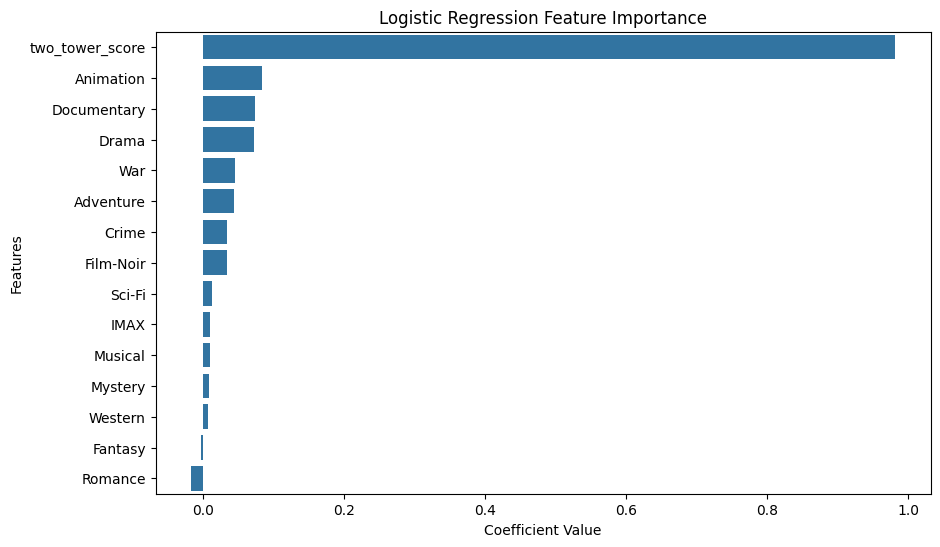

In [15]:
#Logistic regression Feature importance plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_tt.head(15), y=importance_tt.index[:15])
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()


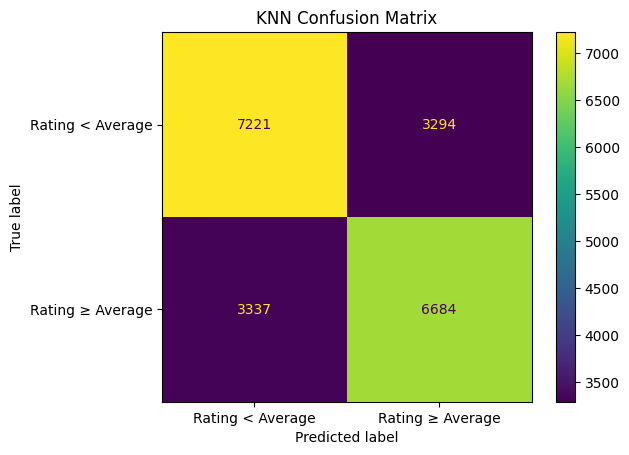

In [16]:
#KNN confusion Matrix

cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rating < Average", "Rating ≥ Average"])
disp.plot()

plt.title("KNN Confusion Matrix")
plt.show()


Our KNN model has an accuracy of about 69%, a precision of 69%, and a recall of 67%. Meaning our KNN model is good at identifying both good and bad movies fairly evenly, and isn't heavily biased towards one class. However it struggles with borderline movies (missing some higher rated and overrating lower rated movies)

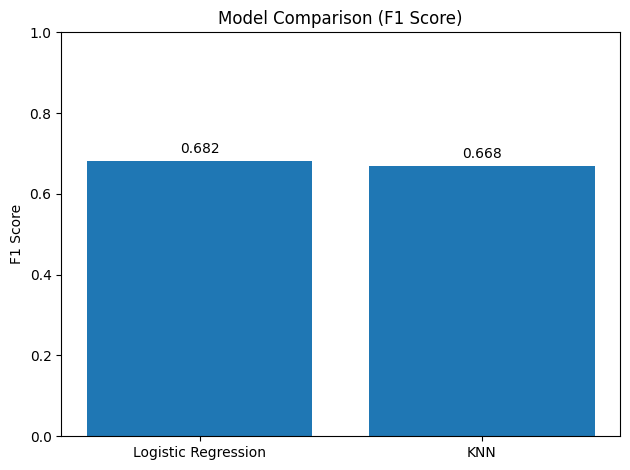

In [17]:
#model scores
models = ['Logistic Regression', 'KNN']
scores = [f1_log, f1_knn]

plt.figure()
plt.bar(models, scores)

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

# Add values on top
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

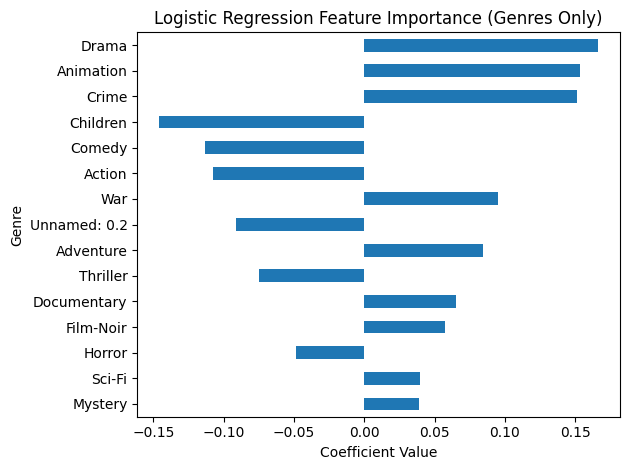

No TT f1 Score: 0.5476139978791092


In [18]:
#For fun, how we do without the TT score

X_no_tt = df_tt.drop(columns=['rating', 'title', 'tag', 'rating_timestamp', 'tag_timestamp', 'userId', 'movieId', '(no genres listed)', 'two_tower_score'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_tt, y_tt, test_size=0.2, random_state=42)

scaler_tt2 = StandardScaler()

X_train2_scaled = scaler_tt2.fit_transform(X_train2)
X_test2_scaled = scaler_tt2.transform(X_test2)

log_model2 = LogisticRegression(max_iter=1000)
log_model2.fit(X_train2_scaled, y_train2)

y_pred_log2 = log_model2.predict(X_test2_scaled)

f1_log2 = f1_score(y_test2, y_pred_log2)

importance2 = pd.Series(log_model2.coef_[0], index=X_no_tt.columns)

importance2 = importance2.reindex(importance2.abs().sort_values(ascending=True).index)

top_n = 15
importance2.tail(top_n).plot(kind='barh')

plt.title("Logistic Regression Feature Importance (Genres Only)")
plt.xlabel("Coefficient Value")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

print("No TT f1 Score:", f1_log2)


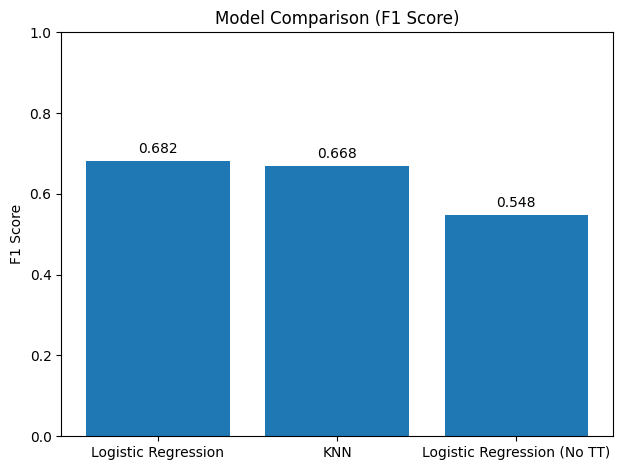

In [19]:
# all 3 model comparisons

models = ['Logistic Regression', 'KNN', 'Logistic Regression (No TT)']
scores = [f1_log, f1_knn, f1_log2]

plt.figure()
plt.bar(models, scores)

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

# Add values on top
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()